In [1]:
import torch
import torch as nn
from torch.utils.data import Dataset,DataLoader


In [2]:
import os
os.chdir("../")

In [3]:
# Dataset class adapted from authors https://github.com/isaaccorley/torchrs 
import os
import json
from typing import List, Dict

import torch
import torchvision.transforms as T
from PIL import Image


class RSICD(torch.utils.data.Dataset):
    """ Image Captioning Dataset from 'Exploring Models and Data for
    Remote Sensing Image Caption Generation', Lu et al. (2017)
    https://arxiv.org/abs/1712.07835

    'RSICD is used for remote sensing image captioning task. more than ten thousands
    remote sensing images are collected from Google Earth, Baidu Map, MapABC, Tianditu.
    The images are fixed to 224X224 pixels with various resolutions. The total number of
    remote sensing images are 10921, with five sentences descriptions per image.'
    """
    splits = ["train", "val", "test"]

    def __init__(
        self,
        root: str = "data",
        split: str = "train",
        transform: T.Compose = T.Compose([T.ToTensor()])
    ):
        assert split in self.splits
        self.root = root
        self.transform = transform
        self.captions = self.load_captions(os.path.join(root, "dataset_rsicd.json"), split)
        self.image_root = "RSICD_images"

    @staticmethod
    def load_captions(path: str, split: str) -> List[Dict]:
        with open(path) as f:
            captions = json.load(f)["images"]
        return [c for c in captions if c["split"] == split]

    def __len__(self) -> int:
        return len(self.captions)

    def __getitem__(self, idx: int) -> Dict:
        captions = self.captions[idx]
        path = os.path.join(self.root, self.image_root, captions["filename"])
        x = Image.open(path).convert("RGB")
        x = self.transform(x)
        sentences = [sentence["raw"] for sentence in captions["sentences"]]
        return dict(x=x, captions=sentences)






Since our __getitem__ returns a image tensot with list of 5 raw captions(strings)

In [4]:
import os
print(os.getcwd())

/home/suyog/Projects/rsicd-image-captioning


In [5]:
#first load the split
train_dataset = RSICD(root="data",split='train')


lets collect all the captions in a list inside our dataset

In [6]:
all_captions = []

for item in train_dataset:
    for captions in item['captions']:
        all_captions.append(captions)

In [7]:
len(all_captions),all_captions[5:10]

(43670,
 ['some planes are parked in an airport .',
  'the airport here is full of airplanes and containers .',
  'the airport here is full of airplanes and containers .',
  'some planes are parked in an airport .',
  'some planes are parked in an airport .'])

we have around 43 thousand captions in here

### Preprocessing
we have done some pretty basic preprocessing steps because the captions are fairly clean.

In [8]:
import re

def preprocess(captions: str) -> list:
    captions = captions.lower().strip()
    captions = re.sub(r"([?.!,])", r" \1 ", captions)# add space puntuation

    captions = re.sub(r"[^a-zA-Z?.!,]+", " ", captions)# remove unwanted characters

    captions = re.sub(r'\s+', ' ', captions).strip()

    tokens = captions.split()

    return tokens

In [9]:
tokenized_captions = []
for c in all_captions:
    tokenized_captions.append(preprocess(c))
    


In [10]:
tokenized_captions[1]

['many',
 'planes',
 'are',
 'parked',
 'next',
 'to',
 'a',
 'long',
 'building',
 'in',
 'an',
 'airport',
 '.']

We are using the simplest form of tokenization, wordpiece tokenization.

### Word frequencies
Lets see the word frequency of our captions

In [11]:
from collections import Counter

word_counter = Counter()

for tokens in tokenized_captions:
    word_counter.update(tokens) ## adds the count instead of replacing

In [12]:
print(f"The unique words present in captions {len(word_counter)} words")

The unique words present in captions 2326 words


In [13]:
word_counter.most_common(10)

[('.', 43670),
 ('a', 41743),
 ('are', 25698),
 ('green', 21129),
 ('many', 18873),
 ('in', 17515),
 ('trees', 17337),
 ('and', 16627),
 ('of', 15084),
 ('the', 14158)]

**Note**: We add '.' because the model could learn when the end of sentence is

Some words which appear less than a certain thershold like maybe 5 adds noise so it is good we remove them

In [14]:
min_freq = 2

vocab_words = [word for word, freq in word_counter.items() if freq >=min_freq]

print(f"Vocab size after applying the threshold : {len(vocab_words)}")

Vocab size after applying the threshold : 1717


Lets add special tokens like <PAD>, <SOS>,<EOS>,<UNK> in our vocab

 1) < PAD > - Used to make the sequence same
 2) < SOS > - Indicate start of sentence
 3) < EOS > - Indicate the end of sentence
 4) < UNK > - Replaces the rare words not found in vocab

In [15]:
special_tokens = ['<PAD>','<SOS>','<EOS>','<UNK>']

vocab = special_tokens + vocab_words

In [16]:
#create mappings

word2idx = {word: idx for idx,word in enumerate(vocab)}
idx2word = {idx: word for word,idx in word2idx.items()}






In [17]:
len(vocab)

1721

In [18]:
def caption_to_indices(tokens, word2idx):
    indices = [word2idx.get(word, word2idx['<UNK>']) for word in tokens]
    indices = [word2idx['<SOS>']] + indices + [word2idx['<EOS>']]
    return indices


In [19]:
import torch
from torch import nn
from torchvision import models

efficient_netb0 = models.efficientnet_b0(pretrained=True)


class Encoder(nn.Module):
    def __init__(self,encoded_dim,projection_dim):
        super().__init__()
        self.encoder = nn.Sequential(*list(efficient_netb0.children())[:-1])
        self.fc = nn.Linear(encoded_dim,projection_dim) # project to same dim as decoder embedding


    def forward(self,images):
        features = self.encoder(images) #(B,1280,1,1)
        features = features.flatten(start_dim =1)
        #features = features.view(features.size(0),-1) # (B,1280)
        features = self.fc(features)

        return features


/home/suyog/anaconda3/envs/rsicd/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/suyog/anaconda3/envs/rsicd/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
import torch
from torch import nn

class Decoder(nn.Module):
    def __init__(self,embed_dim,hidden_dim,vocab_size=len(vocab),num_layers = 1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embed_dim)
        self.lstm = nn.LSTM(embed_dim,hidden_dim,num_layers,batch_first = True)
        self.fc = nn.Linear(hidden_dim,vocab_size)

    def forward(self, captions, features):
        # captions: (B, T)
        embeddings = self.embedding(captions)  # (B, T, embed_dim)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)  # prepend image feature
        outputs, _ = self.lstm(embeddings)  # (B, T+1, hidden_dim)
        outputs = self.fc(outputs)  # (B, T+1, vocab_size)
        return outputs

In [21]:
class ImageCaptioningModel(nn.Module):
    def __init__(self,Encoder,Decoder):
        super().__init__()
        self.encoder = Encoder
        self.decoder = Decoder
        
    def forward(self,image,captions):
        features = self.encoder(image)
        output = self.decoder(captions,features)
        return output

In [22]:
Encoded_dim = 1280 # this becuase of efficientNet
Projected_dim = 512

In [23]:
encoder = Encoder(encoded_dim=Encoded_dim,projection_dim=Projected_dim)
decoder = Decoder(embed_dim=Projected_dim,hidden_dim=512,vocab_size=len(vocab))

In [24]:
base_model = ImageCaptioningModel(encoder,decoder)
EPOCHS = 10

criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<PAD>'])

optimizer = torch.optim.Adam(base_model.parameters(),lr = 0.001)

In [25]:
from torch.nn.utils.rnn import pad_sequence

import random
def collate_fn(batch):
    images = []
    captions = []
    for item in batch:
        img = item['x']
        cap = random.choice(item['captions'])  # Randomly select one caption
        cap_tokens = preprocess(cap)
        cap_indices = caption_to_indices(cap_tokens, word2idx)
        images.append(img)
        captions.append(torch.tensor(cap_indices))
    
    images = torch.stack(images)
    captions = pad_sequence(captions, batch_first=True, padding_value=word2idx['<PAD>'])
    return images, captions

In [26]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True,collate_fn=collate_fn)

In [27]:
device = "cuda" if torch.cuda.is_available()  else "cpu"
device

'cuda'

In [28]:
val_dataset = RSICD(root="data", split="val")
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [35]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torchvision import models
from tqdm import tqdm  # For progress bar

# Diagnostic output (run once)
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Compute Capability: {torch.cuda.get_device_capability(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Update EfficientNet weights
efficient_netb0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Initialize model
encoder = Encoder(encoded_dim=Encoded_dim, projection_dim=Projected_dim)
decoder = Decoder(embed_dim=Projected_dim, hidden_dim=512, vocab_size=len(vocab))
model = ImageCaptioningModel(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<PAD>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training and validation loops
val_dataset = RSICD(root="data", split="val")
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Print shapes for the first batch only to verify
first_batch = True

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1} Training", leave=False)
    
    for images, captions in train_progress:
        images, captions = images.to(device), captions.to(device)
        inputs = captions[:, :-1]  # (batch_size, T)
        targets = captions[:, 1:]  # (batch_size, T)
        
        # Print shapes for the first batch of the first epoch
        if first_batch and epoch == 0:
            print(f"Train - Images shape: {images.shape}")
            print(f"Train - Inputs shape: {inputs.shape}")
            print(f"Train - Targets shape: {targets.shape}")
        
        outputs = model(images, inputs)  # (batch_size, T+1, vocab_size)
        
        # Print outputs shape for the first batch of the first epoch
        if first_batch and epoch == 0:
            print(f"Train - Outputs shape: {outputs.shape}")
            first_batch = False
        
        # Compute loss
        loss = criterion(outputs[:, 1:, :].reshape(-1, len(vocab)), targets.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_train_loss += loss.item()
        
        # Update progress bar with current batch loss
        train_progress.set_postfix({"Batch Loss": loss.item()})
    
    # Validation loop
    model.eval()
    total_val_loss = 0
    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1} Validation", leave=False)
    first_batch = True  # Reset for validation
    
    with torch.no_grad():
        for images, captions in val_progress:
            images, captions = images.to(device), captions.to(device)
            inputs = captions[:, :-1]  # (batch_size, T)
            targets = captions[:, 1:]  # (batch_size, T)
            
            # Print shapes for the first batch of the first epoch
            if first_batch and epoch == 0:
                print(f"Val - Images shape: {images.shape}")
                print(f"Val - Inputs shape: {inputs.shape}")
                print(f"Val - Targets shape: {targets.shape}")
            
            outputs = model(images, inputs)  # (batch_size, T+1, vocab_size)
            
            # Print outputs shape for the first batch of the first epoch
            if first_batch and epoch == 0:
                print(f"Val - Outputs shape: {outputs.shape}")
                first_batch = False
            
            # Compute loss
            loss = criterion(outputs[:, 1:, :].reshape(-1, len(vocab)), targets.reshape(-1))
            total_val_loss += loss.item()
            
            # Update progress bar with current batch loss
            val_progress.set_postfix({"Batch Loss": loss.item()})
    
    # Print epoch summary
    print(f"Epoch {epoch+1}, Train Loss: {total_train_loss/len(train_loader):.4f}, "
          f"Val Loss: {total_val_loss/len(val_loader):.4f}")

PyTorch Version: 2.0.1+cu118
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
Compute Capability: (8, 6)
CUDA Version: 11.8
Using device: cuda


Epoch 1 Training:   0%|          | 1/273 [00:00<01:04,  4.19it/s, Batch Loss=7.43]

Train - Images shape: torch.Size([32, 3, 224, 224])
Train - Inputs shape: torch.Size([32, 25])
Train - Targets shape: torch.Size([32, 25])
Train - Outputs shape: torch.Size([32, 26, 1721])


Epoch 1 Validation:   6%|▌         | 2/35 [00:00<00:02, 12.56it/s, Batch Loss=2.53] 

Val - Images shape: torch.Size([32, 3, 224, 224])
Val - Inputs shape: torch.Size([32, 27])
Val - Targets shape: torch.Size([32, 27])
Val - Outputs shape: torch.Size([32, 28, 1721])


...

Epoch 6, Train Loss: 1.6145, Val Loss: 1.9317


Epoch 7, Train Loss: 1.5310, Val Loss: 1.8220


Epoch 8, Train Loss: 1.4631, Val Loss: 1.8176


Epoch 9, Train Loss: 1.3999, Val Loss: 1.7934


Epoch 10, Train Loss: 1.3463, Val Loss: 1.7669


In [36]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save the final model
final_checkpoint = {
    'epoch': EPOCHS,  # Assuming EPOCHS is the total number of epochs trained
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
final_model_path = os.path.join(checkpoint_dir, "final_model.pt")
torch.save(final_checkpoint, final_model_path)
print(f"Saved final model to {final_model_path}")

Saved final model to checkpoints/final_model.pt


In [37]:

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model (must match the architecture used during training)
encoder = Encoder(encoded_dim=Encoded_dim, projection_dim=Projected_dim)
decoder = Decoder(embed_dim=Projected_dim, hidden_dim=512, vocab_size=len(vocab))
model = ImageCaptioningModel(encoder, decoder).to(device)

# Load the saved model
final_model_path = "checkpoints/final_model.pt"
checkpoint = torch.load(final_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']}")

# Inference function
def generate_caption(model, image, word2idx, idx2word, max_length=20, device=device):
    model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0)  # Add batch dimension: (1, 3, 224, 224)
        features = model.encoder(image)  # (1, embed_dim)
        caption = [word2idx['<SOS>']]
        for _ in range(max_length):
            inputs = torch.tensor(caption, device=device).unsqueeze(0)  # (1, T)
            outputs = model.decoder(inputs, features)  # (1, T+1, vocab_size)
            next_word = outputs[:, -1, :].argmax(dim=-1)  # (1,)
            caption.append(next_word.item())
            if next_word.item() == word2idx['<EOS>']:
                break
        return [idx2word[idx] for idx in caption[1:-1]]  # Exclude <SOS> and <EOS>

# Test inference on a sample training image
sample_image, sample_captions = train_dataset[0]['x'], train_dataset[0]['captions']
generated_caption = generate_caption(model, sample_image, word2idx, idx2word)
print(f"Training Image - Generated Caption: {' '.join(generated_caption)}")
print(f"Training Image - Ground Truth Captions: {sample_captions}")

# Test inference on a sample validation image
val_image, val_captions = val_dataset[0]['x'], val_dataset[0]['captions']
generated_caption = generate_caption(model, val_image, word2idx, idx2word)
print(f"Validation Image - Generated Caption: {' '.join(generated_caption)}")
print(f"Validation Image - Ground Truth Captions: {val_captions}")

Loaded model from epoch 10
Training Image - Generated Caption: many planes are parked in an airport .
Training Image - Ground Truth Captions: ['many planes are parked next to a long building in an airport .', 'many planes are parked next to a long building in an airport .', 'many planes are parked next to a long building in an airport .', 'many planes are parked next to a long building in an airport .', 'many planes are parked next to a long building in an airport .']
Validation Image - Generated Caption: many planes are in an airport near some green trees .
Validation Image - Ground Truth Captions: ['the tarmac and airport runways divide the field into several orderly arranged rounded rectangles  next to which is buildings and a road .', 'the tarmac and airport runways divide the field into several orderly arranged rounded rectangles  next to which is buildings and a road .', 'a brown ground divided by the grey runway .', 'we can see a simple termial building and an apron connceted wi

Using device: cuda
Loaded model from epoch 10
Loaded and preprocessed image: notebooks/p.png
Generated Caption: many green trees are around an irregular pond .


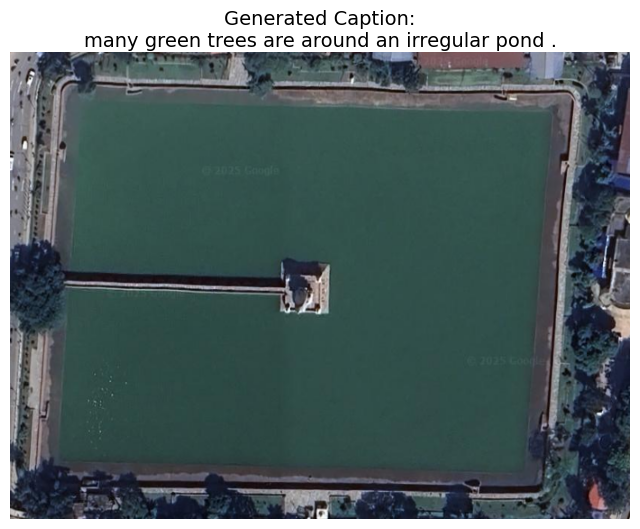

In [34]:
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize model (must match the architecture used during training)
encoder = Encoder(encoded_dim=Encoded_dim, projection_dim=Projected_dim)
decoder = Decoder(embed_dim=Projected_dim, hidden_dim=512, vocab_size=len(vocab))
model = ImageCaptioningModel(encoder, decoder).to(device)

# Load the saved model
final_model_path = "checkpoints/final_model.pt"
checkpoint = torch.load(final_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']}")

# Image preprocessing (matches RSICD dataset)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),          # Convert to tensor
    # Add normalization if used in training, e.g.,
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Inference function
def generate_caption(model, image, word2idx, idx2word, max_length=20, device=device):
    model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0)  # (1, 3, 224, 224)
        features = model.encoder(image)  # (1, embed_dim)
        caption = [word2idx['<SOS>']]
        for _ in range(max_length):
            inputs = torch.tensor(caption, device=device).unsqueeze(0)  # (1, T)
            outputs = model.decoder(inputs, features)  # (1, T+1, vocab_size)
            next_word = outputs[:, -1, :].argmax(dim=-1)  # (1,)
            caption.append(next_word.item())
            if next_word.item() == word2idx['<EOS>']:
                break
        return [idx2word[idx] for idx in caption[1:-1]]  # Exclude <SOS> and <EOS>

# Load and preprocess custom image
image_path ="notebooks/p.png"  # Replace with your image path
try:
    custom_image = Image.open(image_path).convert("RGB")  # Load image and convert to RGB
    custom_image_tensor = preprocess(custom_image)  # Apply preprocessing
    print(f"Loaded and preprocessed image: {image_path}")
    
    # Generate caption
    generated_caption = generate_caption(model, custom_image_tensor, word2idx, idx2word)
    caption_text = " ".join(generated_caption)
    print(f"Generated Caption: {caption_text}")
    
    # -------- Matplotlib Visualization --------
    plt.figure(figsize=(8, 8))
    plt.imshow(custom_image)  # Show original image (not tensor, so caption aligns visually)
    plt.axis("off")
    plt.title(f"Generated Caption:\n{caption_text}", fontsize=14, wrap=True)
    plt.show()

except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}")
except Exception as e:
    print(f"Error processing image: {e}")


In [40]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchmetrics.text.bleu import BLEUScore
from pycocoevalcap.cider.cider import Cider
from nltk.translate.meteor_score import single_meteor_score
import nltk
nltk.download('wordnet')

# --- Load model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder(encoded_dim=Encoded_dim, projection_dim=Projected_dim)
decoder = Decoder(embed_dim=Projected_dim, hidden_dim=512, vocab_size=len(vocab))
model = ImageCaptioningModel(encoder, decoder).to(device)

# Load saved state_dict (only model)
checkpoint = torch.load("checkpoints/final_model.pt", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# --- Prepare test loader ---
test_dataset = RSICD(root="data", split="test")
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# --- Function to generate caption for a single image ---
# --- Function to generate caption with beam search ---
def generate_caption_beam(image, beam_width=3, max_len=50):
    model.eval()
    image = image.unsqueeze(0).to(device)  # add batch dim

    # Each element in beams: (sequence, score)
    beams = [( [word2idx['<SOS>']], 0.0 )]

    with torch.no_grad():
        for _ in range(max_len):
            new_beams = []
            for seq, score in beams:
                if seq[-1] == word2idx['<EOS>']:
                    # Keep finished sequences as is
                    new_beams.append((seq, score))
                    continue

                inputs = torch.tensor(seq).unsqueeze(0).to(device)
                outputs = model(image, inputs)  # (1, seq_len, vocab_size)
                log_probs = torch.log_softmax(outputs[0, -1], dim=-1)

                # Get top k candidates for this step
                topk_probs, topk_indices = torch.topk(log_probs, beam_width)
                for k in range(beam_width):
                    next_seq = seq + [topk_indices[k].item()]
                    next_score = score + topk_probs[k].item()
                    new_beams.append((next_seq, next_score))

            # Keep top beam_width sequences
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

            # If all beams are finished, break early
            if all(seq[-1] == word2idx['<EOS>'] for seq, _ in beams):
                break

    # Choose the beam with the highest score
    best_seq = beams[0][0]

    # Convert to string
    caption_words = [vocab[idx] for idx in best_seq[1:] if idx not in (word2idx['<PAD>'], word2idx['<EOS>'])]
    return " ".join(caption_words)


# --- Collect predictions and references ---
all_preds = []
all_refs = []

for images, captions in tqdm(test_loader, desc="Generating captions"):
    for img, cap in zip(images, captions):
        pred_caption = generate_caption(img)
        all_preds.append(pred_caption)

        # Reference captions as strings
        ref_words = [vocab[i.item()] for i in cap if i.item() not in (word2idx['<PAD>'], word2idx['<SOS>'], word2idx['<EOS>'])]
        all_refs.append([" ".join(ref_words)])  # wrap in list for multiple references

# --- BLEU Scores ---
# BLEU-1 to BLEU-4
bleu1 = BLEUScore(n_gram=1)
bleu2 = BLEUScore(n_gram=2)
bleu3 = BLEUScore(n_gram=3)
bleu4 = BLEUScore(n_gram=4)

# Compute scores
score1 = bleu1(all_preds, all_refs)
score2 = bleu2(all_preds, all_refs)
score3 = bleu3(all_preds, all_refs)
score4 = bleu4(all_preds, all_refs)

print(f"BLEU-1: {score1:.4f}")
print(f"BLEU-2: {score2:.4f}")
print(f"BLEU-3: {score3:.4f}")
print(f"BLEU-4: {score4:.4f}")

# # --- METEOR Score ---
# meteor_scores = [single_meteor_score(ref[0], pred) for ref, pred in zip(all_refs, all_preds)]
# meteor_avg = sum(meteor_scores) / len(meteor_scores)
# print(f"METEOR: {meteor_avg:.4f}")

# --- CIDEr Score ---
cider_scorer = Cider()
cider_score, _ = cider_scorer.compute_score({i: refs for i, refs in enumerate(all_refs)},
                                            {i: [pred] for i, pred in enumerate(all_preds)})
print(f"CIDEr: {cider_score:.4f}")


[nltk_data] Downloading package wordnet to /home/suyog/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Generating captions: 100%|██████████| 35/35 [01:17<00:00,  2.22s/it]


BLEU-1: 0.3297
BLEU-2: 0.1787
BLEU-3: 0.1152
BLEU-4: 0.0819
CIDEr: 0.8095


In [32]:

os.getcwd()

'/home/suyog/Projects/rsicd-image-captioning'